## 19. Μάθηση με αβεβαιότητα

<!-- book-intro-cell -->
### Εισαγωγή από το βιβλίο

Τυπικά, στα μοντέλα μηχανικής μάθησης το τελικό αποτέλεσμα είναι μια πρόβλεψη . Αυτή μπορεί να είναι η εκτίμηση της τιμής ενός ακινήτου, η πρόβλεψη της θερμοκρασίας της επόμενης ημέρας, η πιθανότητα μιας κατηγορίας, όπως για το αν ένα κείμενο είναι τοξικό. Αυτές οι προβλέψεις, όμως, δεν μας πληροφορούν για την αξιοπιστία της απάντησης.

Για παράδειγμα, μπορεί δύο διαφορετικά μοντέλα να δίνουν την ίδια ακριβώς πρόβλεψη, αλλά να διαφέρουν σημαντικά ως προς τη σταθερότητα και την ακρίβειά τους. Το ένα μπορεί να χαρακτηρίζεται από μικρά σφάλματα σε παρόμοια δεδομένα, ενώ το άλλο μπορεί να έχει μεγάλη διασπορά σφαλμάτων. Αν περιοριστούμε στη σημειακή πρόβλεψη, τότε δεν υπάρχει τρόπος να διακρίνουμε αυτές τις δύο περιπτώσεις.

Σε πραγματικές εφαρμογές, η πληροφορία για την αβεβαιότητα μπορεί να είναι κρίσιμη για τη λήψη αποφάσεων. Σε ένα ιατρικό σύστημα υποστήριξης διαγνώσεων, μια αβέβαιη πρόβλεψη μπορεί να οδηγήσει σε περαιτέρω εξετάσεις αντί για άμεση θεραπεία. Σε ένα επενδυτικό πλαίσιο, μια πρόβλεψη με μεγάλη αβεβαιότητα μπορεί να οδηγήσει σε μια πιο συντηρητική στρατηγική.


In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

# Φόρτωση δεδομένων
data = fetch_california_housing()
X, y = data.data, data.target

# Διαχωρισμός: train / calibration / test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_cal, X_test, y_cal, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Εκπαίδευση μοντέλου
model = LinearRegression()
model.fit(X_train, y_train)

# Calibration residuals
y_cal_pred = model.predict(X_cal)
residuals = np.abs(y_cal - y_cal_pred)

# Επιλογή alpha
alpha = 0.1
q = np.quantile(residuals, 1 - alpha)

# Προβλέψεις στο test set
y_test_pred = model.predict(X_test)

lower = y_test_pred - q
upper = y_test_pred + q

# Empirical coverage
coverage = np.mean((y_test >= lower) & (y_test <= upper))

print(f"Coverage: {coverage:.3f}")
print(f"Interval width (mean): {np.mean(upper - lower):.3f}")

Coverage: 0.907
Interval width (mean): 2.231


### 19.3 Εφαρμογή: Συμμορφωτική πρόβλεψη παροιμιών

Coverage: 0.937
Average set size: 14.90


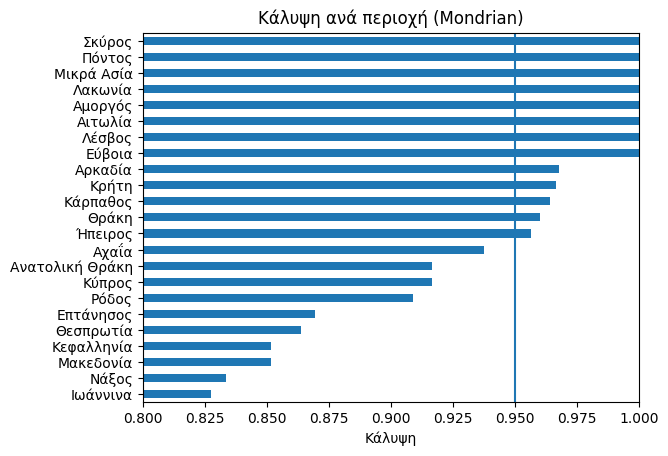

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

root = 'https://github.com/greek-proverb-atlas/proverbs.gr/raw/refs/heads/main/data/'
balanced_corpus = pd.read_csv(
    root+"balanced_corpus.csv",
    index_col=0).reset_index()

train, test = train_test_split(balanced_corpus, test_size=0.05, random_state=2023)
train, dev = train_test_split(train, test_size=test.shape[0], random_state=2023)

vect = TfidfVectorizer(
    ngram_range=(2, 5),
    analyzer="char",
    max_df=0.2,
    min_df=1,
    lowercase=True
)

lr = Pipeline([
    ('vect', vect),
    ('clf', LogisticRegression(max_iter=1000))
])

lr.fit(train.text, train.area)

# Mondrian
probs_dev = lr.predict_proba(dev.text)
classes = lr.classes_
y_dev = dev.area.values

# Nonconformity
scores_dev = []
for i in range(len(y_dev)):
    true_class = y_dev[i]
    class_index = np.where(classes == true_class)[0][0]
    score = 1 - probs_dev[i, class_index]
    scores_dev.append(score)

scores_dev = np.array(scores_dev)

# Mondrian: q ανά περιοχή
alpha = 0.05
q_per_class = {}
for c in classes:
    mask = (y_dev == c)
    class_scores = scores_dev[mask]
    q_per_class[c] = np.quantile(class_scores, 1 - alpha)

# Prediction sets
probs_test = lr.predict_proba(test.text)
prediction_sets = []
for i in range(len(test)):
    p = probs_test[i]
    labels = []
    for j, c in enumerate(classes):
        score = 1 - p[j]
        if score <= q_per_class[c]:
            labels.append(c)
    prediction_sets.append(labels)
test["mondrian_set"] = prediction_sets

# Coverage
coverage = np.mean([
    test.iloc[i].area in prediction_sets[i]
    for i in range(len(test))
])
print(f"Coverage: {coverage:.3f}")

# Μέγεθος συνόλων
set_sizes = [len(s) for s in prediction_sets]
print(f"Average set size: {np.mean(set_sizes):.2f}")

# Σύγκριση ανά περιοχή
per_class_coverage = {}
for c in classes:
    mask = (test.area == c)
    if mask.sum() > 0:
        per_class_coverage[c] = np.mean([
            test.iloc[i].area in prediction_sets[i]
            for i in np.where(mask)[0]
        ])

coverage_series = pd.Series(per_class_coverage).sort_values()
plt.figure()
coverage_series.plot(kind='barh')
plt.axvline(0.95)  # target coverage
plt.xlabel("Κάλυψη")
plt.xlim(0.8,1)
plt.title("Κάλυψη ανά περιοχή (Mondrian)")
plt.show()

**Κάλυψη ανά περιοχή για τη Mondrian συμμορφωτική πρόβλεψη γεωγραφικής προέλευσης παροιμιών.** Για κάθε περιοχή υπολογίζεται το ποσοστό των παραδειγμάτων ελέγχου στα οποία η πραγματική περιοχή περιλαμβάνεται στο σύνολο προβλέψεων του μοντέλου. Η κατακόρυφη γραμμή στο 0.95 δείχνει την επιθυμητή κάλυψη για επίπεδο σημαντικότητας α = 0.05, ενώ οι αποκλίσεις ανά περιοχή δείχνουν πού το μοντέλο είναι περισσότερο ή λιγότερο αξιόπιστο.

In [ ]:
unknown_df = pd.read_csv(root+"unlocated.csv")
probs_unknown = lr.predict_proba(unknown_df.text)
prediction_sets_unknown = []
for i in range(len(unknown_df)):
    p = probs_unknown[i]
    labels = []
    for j, c in enumerate(classes):
        score = 1 - p[j]
        if score <= q_per_class[c]:
            labels.append(c)
    prediction_sets_unknown.append(labels)
unknown_df["predicted_regions"] = prediction_sets_unknown

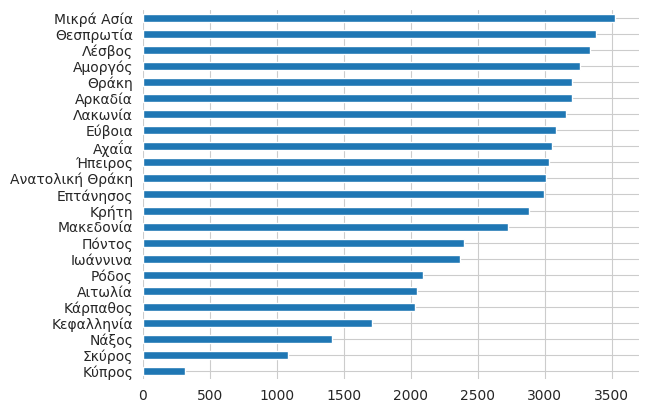

In [ ]:
# ποιες περιοχές εμφανίζονται πιο συχνά
from collections import Counter
import seaborn as sns
sns.set_style('whitegrid')
all_preds = [label for s in prediction_sets_unknown for label in s]
pd.Series(Counter(all_preds)).sort_values().plot.barh();
sns.despine(left=True, bottom=True);

**Συχνότητα εμφάνισης των περιοχών στα σύνολα πρόβλεψης για παροιμίες χωρίς γνωστή γεωγραφική προέλευση.** Κάθε μπάρα δείχνει πόσες φορές μια περιοχή περιλαμβάνεται στα σύνολα συμμορφωτικής πρόβλεψης των άγνωστων παραδειγμάτων. Οι περιοχές με μεγαλύτερες τιμές εμφανίζονται συχνότερα ως πιθανές προελεύσεις, χωρίς αυτό να σημαίνει ότι αποτελούν μοναδική πρόβλεψη για κάθε παροιμία, αφού κάθε παράδειγμα μπορεί να συνοδεύεται από περισσότερες από μία πιθανές περιοχές.

In [ ]:
# Πολύ σίγουρες περιπτώσεις
small_sets_df = unknown_df[unknown_df["set_size"] <= 5].copy()
small_sets_df = small_sets_df.sort_values(by="set_size")
small_sets_df[["text", "predicted_regions", "set_size"]].head()

,text,predicted_regions,set_size
3327,"Ανdάσ σου διούμ πκιάννε, τζ' ανdάθ θωρείς, μεν...","[Κρήτη, Κύπρος]",2
1023,Αυτός είναι Παύλος,"[Αιτωλία, Αχαΐα, Επτάνησος, Θεσπρωτία]",4
2792,Το λόγον ατ δύο κ' εφτεάει,"[Ήπειρος, Επτάνησος, Λέσβος, Πόντος]",4
2519,"Αρμάστου αρμάστου, τσαί dεpοί τωρεί dυο μέραι ...","[Εύβοια, Κάρπαθος, Λέσβος, Σκύρος]",4
2690,Αυτός είναι Ηρώδης,"[Αιτωλία, Αχαΐα, Επτάνησος, Θεσπρωτία, Λέσβος]",5


**Παροιμίες χωρίς γνωστή γεωγραφική προέλευση για τις οποίες το σύνολο συμμορφωτικής πρόβλεψης είναι μικρό.** Η στήλη `predicted_regions` περιέχει τις περιοχές που παραμένουν πιθανές σύμφωνα με το μοντέλο, ενώ η στήλη `set_size` δείχνει το πλήθος αυτών των περιοχών. Μικρότερο σύνολο πρόβλεψης σημαίνει ότι το μοντέλο αποκλείει περισσότερες εναλλακτικές περιοχές και εμφανίζει μικρότερη αβεβαιότητα για το συγκεκριμένο παράδειγμα, χωρίς αυτό να ισοδυναμεί με απόλυτη βεβαιότητα.

In [ ]:
for t in small_sets_df[["text", "predicted_regions", "set_size"]].text.values:
  print(t)

Ανdάσ σου διούμ πκιάννε, τζ' ανdάθ θωρείς, μεν-ι-ζητάς
Αυτός είναι Παύλος
Το λόγον ατ δύο κ' εφτεάει
Αρμάστου αρμάστου, τσαί dεpοί τωρεί dυο μέραι αλοχαρία τσαί bοι λάμπαρα τσαί φωdία
Αυτός είναι Ηρώδης
